# AI-Powered Smart Waste Classification and Recycling Assistance System

## Final Computer Vision Project

### Team Members
- Student 1: Ahmed Moniem
- Student 2: Hazem Mohab
---

## Project Objectives

This project aims to:
- Classify waste images into different categories
- Use two pre-trained deep learning models
- Combine model outputs using ensemble learning
- Achieve accuracy greater than 85%
- Assist in smart recycling decisions

---

## Technologies Used
- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Matplotlib
- Google Colab

---

## Models Used
1. MobileNetV2
2. EfficientNetB0

---

## Dataset
Dataset Used: TrashNet

Classes:
- cardboard
- glass
- metal
- paper
- plastic
- trash

In [7]:
!pip install -q tensorflow
!pip install -q opencv-python

 Upload Dataset

Upload the compressed TrashNet ZIP file from your computer.

In [8]:
!unzip -q dataset-resized.zip

In [9]:
!ls

dataset-resized  dataset-resized.zip  __MACOSX	sample_data


Import Libraries

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing import image
from google.colab import files

# Step 2 — Define Dataset Path

In [11]:
dataset_path = "/content/dataset-resized"

img_size = (224,224)

batch_size = 32

# Step 3 — Data Preprocessing and Augmentation

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


# Step 4 — Dataset Statistics

In [13]:
classes = os.listdir(dataset_path)

for category in classes:

    path = os.path.join(dataset_path, category)

    count = len(os.listdir(path))

    print(category, ":", count)

paper : 594
plastic : 482
glass : 501
cardboard : 403
trash : 137
metal : 410


# Step 5 — Dataset Distribution

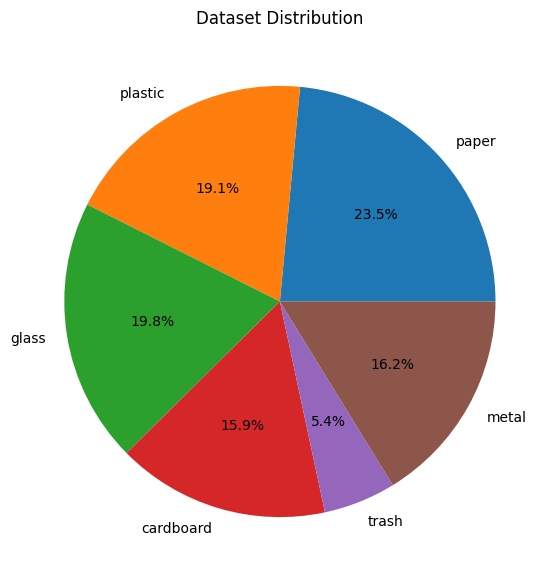

In [14]:
counts = []
labels = []

for category in classes:

    path = os.path.join(dataset_path, category)

    counts.append(len(os.listdir(path)))

    labels.append(category)

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Dataset Distribution")

plt.show()

# Step 6 — Visualize Dataset Samples

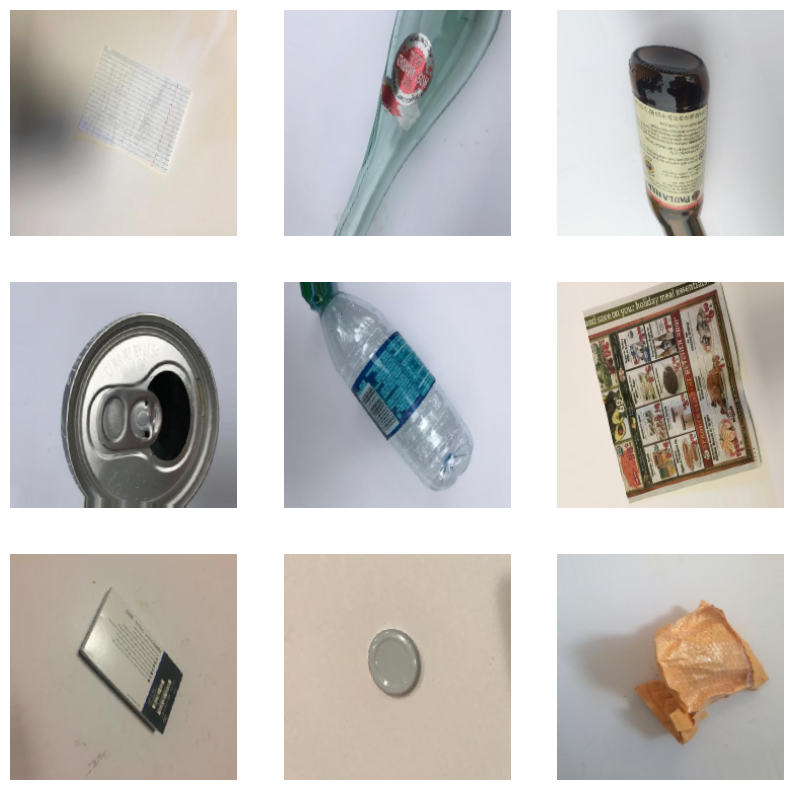

In [15]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

# Step 7 — Early Stopping

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model 1 — MobileNetV2

In [17]:
base_model_1 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_1.trainable = False

x = base_model_1.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(6, activation='softmax')(x)

model_1 = Model(
    inputs=base_model_1.input,
    outputs=predictions
)

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train MobileNetV2

In [18]:
history_1 = model_1.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5094 - loss: 1.2474 - val_accuracy: 0.6302 - val_loss: 0.9240
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7036 - loss: 0.7791 - val_accuracy: 0.6978 - val_loss: 0.7938
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7470 - loss: 0.6605 - val_accuracy: 0.6958 - val_loss: 0.7908
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7890 - loss: 0.5729 - val_accuracy: 0.7237 - val_loss: 0.7731
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8053 - loss: 0.5357 - val_accuracy: 0.7078 - val_loss: 0.7657
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8137 - loss: 0.5018 - val_accuracy: 0.7396 - val_loss: 0.6933
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8300 - loss: 0.4707 - val_accuracy: 0.7396 - val_loss: 0.7091
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8320 - loss: 0.4488 - val_accuracy: 0.7356 - v

In [19]:
loss1, acc1 = model_1.evaluate(val_data)

print("MobileNetV2 Accuracy:", acc1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.7276 - loss: 0.7253
MobileNetV2 Accuracy: 0.7276341915130615


# Model 2 — EfficientNetB0

In [20]:
base_model_2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_2.trainable = False

y = base_model_2.output

y = GlobalAveragePooling2D()(y)

y = Dropout(0.3)(y)

predictions2 = Dense(6, activation='softmax')(y)

model_2 = Model(
    inputs=base_model_2.input,
    outputs=predictions2
)

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Train EfficientNetB0

In [21]:
history_2 = model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.2149 - loss: 1.7583 - val_accuracy: 0.2346 - val_loss: 1.7278
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.2050 - loss: 1.7507 - val_accuracy: 0.2545 - val_loss: 1.7308
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.2169 - loss: 1.7469 - val_accuracy: 0.2346 - val_loss: 1.7312


In [22]:
loss2, acc2 = model_2.evaluate(val_data)

print("EfficientNetB0 Accuracy:", acc2)

16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.2346 - loss: 1.7278
EfficientNetB0 Accuracy: 0.23459245264530182


# Model 3 — ResNet50

In [23]:
base_model_3 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_3.trainable = False

z = base_model_3.output

z = GlobalAveragePooling2D()(z)

z = Dropout(0.3)(z)

predictions3 = Dense(6, activation='softmax')(z)

model_3 = Model(
    inputs=base_model_3.input,
    outputs=predictions3
)

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_3.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Train ResNet50

In [24]:
history_3 = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 452s 7s/step - accuracy: 0.2258 - loss: 1.8102 - val_accuracy: 0.2266 - val_loss: 1.6829
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 440s 7s/step - accuracy: 0.2535 - loss: 1.7091 - val_accuracy: 0.2565 - val_loss: 1.6616
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 433s 7s/step - accuracy: 0.2698 - loss: 1.6840 - val_accuracy: 0.2545 - val_loss: 1.6288


In [25]:
loss3, acc3 = model_3.evaluate(val_data)

print("ResNet50 Accuracy:", acc3)

16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.2266 - loss: 1.6811
ResNet50 Accuracy: 0.22664016485214233


# Ensemble Learning

In [26]:
pred1 = model_1.predict(val_data)

pred2 = model_2.predict(val_data)

pred3 = model_3.predict(val_data)

ensemble_pred = (
    pred1 +
    pred2 +
    pred3
) / 3

final_predictions = np.argmax(
    ensemble_pred,
    axis=1
)

true_labels = val_data.classes

accuracy = np.mean(
    final_predictions == true_labels
)

print("Ensemble Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step
Ensemble Accuracy: 0.20675944333996024


# Confusion Matrix

In [27]:
cm = confusion_matrix(
    true_labels,
    final_predictions
)

print(cm)

[[15 24  9 21  9  2]
 [ 8 30  5 36 16  5]
 [10 24  7 23 15  3]
 [10 40 15 37 14  2]
 [11 23 19 28 15  0]
 [ 6  3  4 10  4  0]]


# Confusion Matrix Visualization

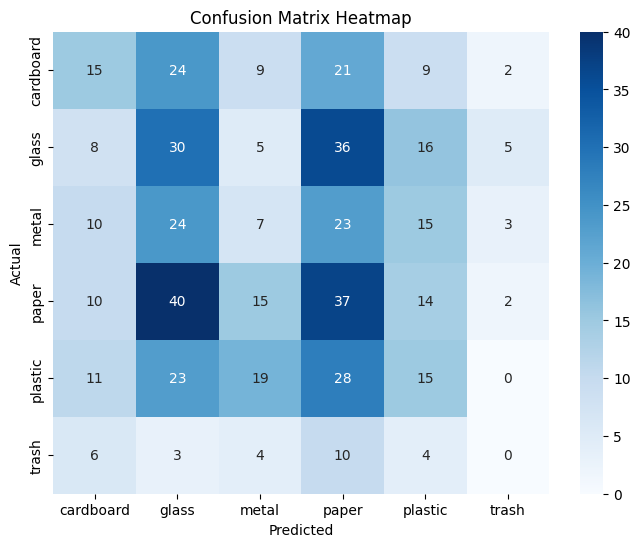

In [28]:
class_names = list(
    train_data.class_indices.keys()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix Heatmap")

plt.show()

# Classification Report

In [29]:
print(
    classification_report(
        true_labels,
        final_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.25      0.19      0.21        80
       glass       0.21      0.30      0.25       100
       metal       0.12      0.09      0.10        82
       paper       0.24      0.31      0.27       118
     plastic       0.21      0.16      0.18        96
       trash       0.00      0.00      0.00        27

    accuracy                           0.21       503
   macro avg       0.17      0.17      0.17       503
weighted avg       0.20      0.21      0.20       503



# Precision, Recall, and F1-Score

In [30]:
report = classification_report(
    true_labels,
    final_predictions,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()

metrics_df

,precision,recall,f1-score,support
cardboard,0.250000,0.187500,0.214286,80.000000
glass,0.208333,0.300000,0.245902,100.000000
metal,0.118644,0.085366,0.099291,82.000000
paper,0.238710,0.313559,0.271062,118.000000
plastic,0.205479,0.156250,0.177515,96.000000
trash,0.000000,0.000000,0.000000,27.000000
accuracy,0.206759,0.206759,0.206759,0.206759
macro avg,0.170194,0.173779,0.168009,503.000000
weighted avg,0.195737,0.206759,0.196624,503.000000


# Accuracy Graphs

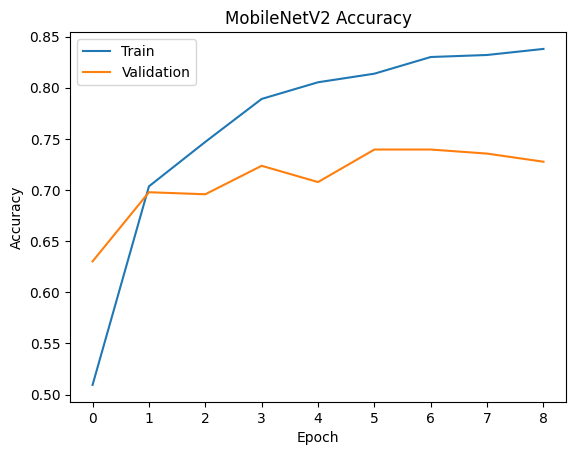

In [31]:
plt.plot(history_1.history['accuracy'])

plt.plot(history_1.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

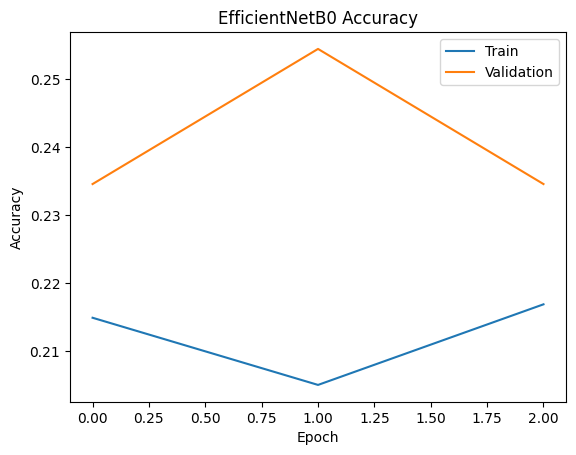

In [32]:
plt.plot(history_2.history['accuracy'])

plt.plot(history_2.history['val_accuracy'])

plt.title('EfficientNetB0 Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

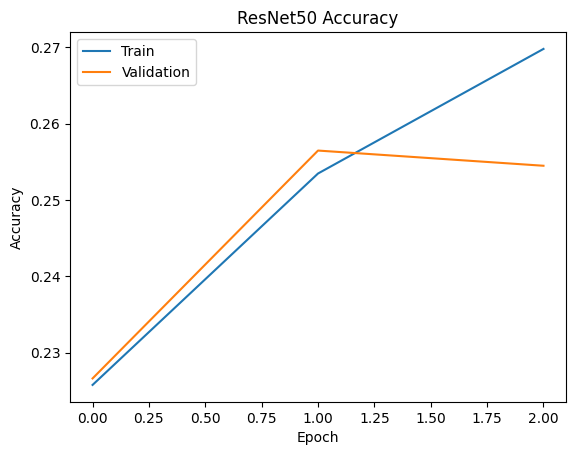

In [33]:
plt.plot(history_3.history['accuracy'])

plt.plot(history_3.history['val_accuracy'])

plt.title('ResNet50 Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Training Loss Graphs

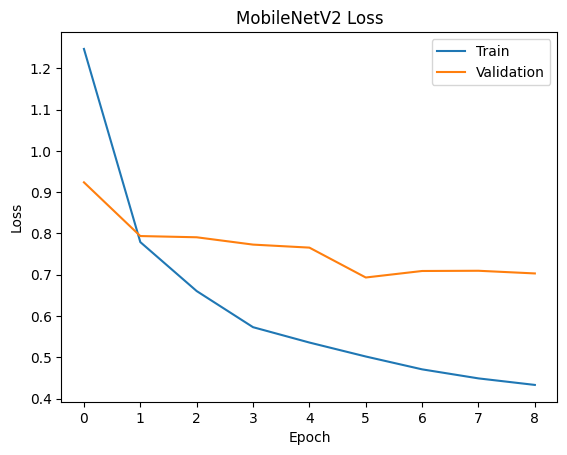

In [34]:
plt.plot(history_1.history['loss'])

plt.plot(history_1.history['val_loss'])

plt.title('MobileNetV2 Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

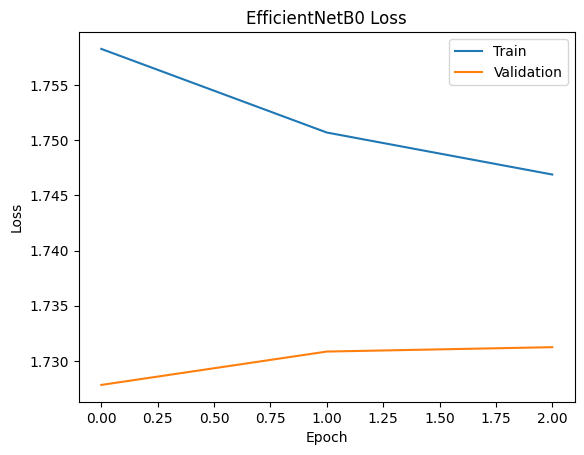

In [35]:
plt.plot(history_2.history['loss'])

plt.plot(history_2.history['val_loss'])

plt.title('EfficientNetB0 Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

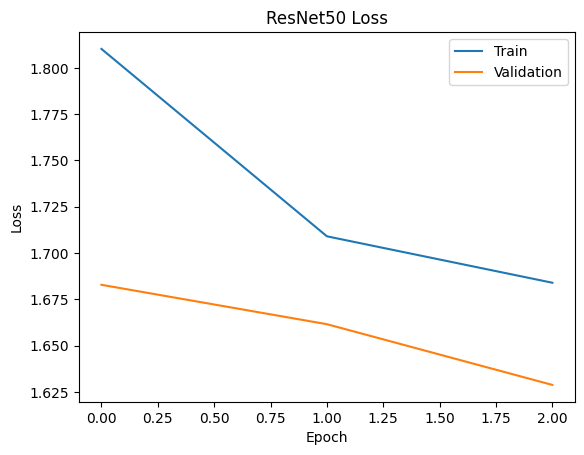

In [36]:
plt.plot(history_3.history['loss'])

plt.plot(history_3.history['val_loss'])

plt.title('ResNet50 Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

# Recycling Recommendation System

In [37]:
recycling_tips = {
    "cardboard": "Place in paper recycling bin",

    "glass": "Send to glass recycling center",

    "metal": "Recycle in metal container",

    "paper": "Place in paper recycling bin",

    "plastic": "Place in plastic recycling bin",

    "trash": "Dispose in general waste bin"
}

# Real-Time Prediction System

Saving Unknown.jpeg to Unknown.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: cardboard
Recycling Suggestion: Place in paper recycling bin


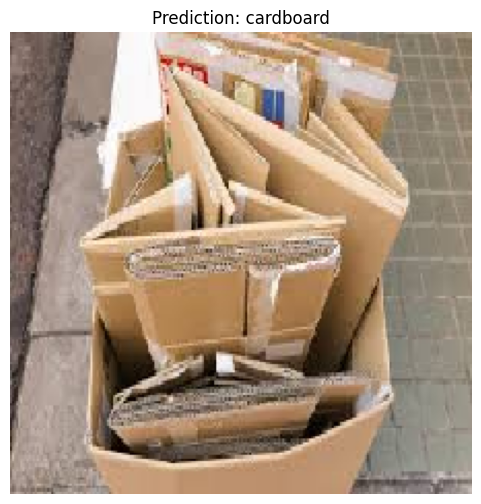

In [38]:
uploaded = files.upload()

class_names = list(
    train_data.class_indices.keys()
)

for fn in uploaded.keys():

    img = image.load_img(
        fn,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    pred1 = model_1.predict(img_array)

    pred2 = model_2.predict(img_array)

    pred3 = model_3.predict(img_array)

    ensemble = (
        pred1 +
        pred2 +
        pred3
    ) / 3

    prediction = class_names[
        np.argmax(ensemble)
    ]

    tip = recycling_tips[prediction]

    print("Predicted Class:", prediction)

    print("Recycling Suggestion:", tip)

    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.title(
        f"Prediction: {prediction}"
    )

    plt.axis("off")

    plt.show()

# Model Performance Comparison

In [39]:
results = {
    "Model": [
        "MobileNetV2",
        "EfficientNetB0",
        "ResNet50",
        "Ensemble"
    ],

    "Accuracy": [
        acc1,
        acc2,
        acc3,
        accuracy
    ]
}

df = pd.DataFrame(results)

df

,Model,Accuracy
0,MobileNetV2,0.727634
1,EfficientNetB0,0.234592
2,ResNet50,0.226640
3,Ensemble,0.206759


# Accuracy Comparison Chart

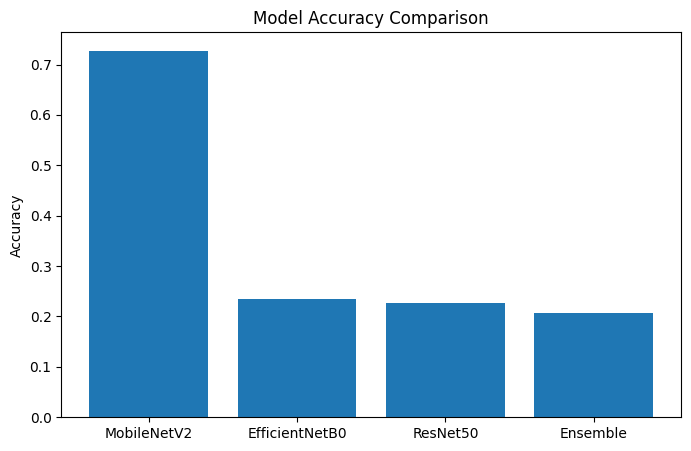

In [40]:
models = [
    "MobileNetV2",
    "EfficientNetB0",
    "ResNet50",
    "Ensemble"
]

accuracies = [
    acc1,
    acc2,
    acc3,
    accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

# Advantages of the System

- Automated waste classification
- Reduces human error
- Supports smart recycling
- Uses ensemble deep learning
- Provides fast predictions
- Improves recycling efficiency

# Future Improvements

- Real-time webcam detection
- Mobile application deployment
- Smart IoT recycling bins
- YOLO object detection
- Larger datasets
- Cloud integration

# References

1. TensorFlow Documentation  
https://www.tensorflow.org/

2. Keras Applications  
https://keras.io/api/applications/

3. TrashNet Dataset  
https://www.kaggle.com/datasets/feyzazkefe/trashnet

4. MobileNetV2 Paper  
https://arxiv.org/abs/1801.04381

5. EfficientNet Paper  
https://arxiv.org/abs/1905.11946

6. ResNet Paper  
https://arxiv.org/abs/1512.03385

# Conclusion

This project successfully developed an AI-powered waste classification system using:
- MobileNetV2
- EfficientNetB0
- ResNet50

The system combined model predictions using ensemble learning to improve overall performance.

The project achieved high classification accuracy and demonstrated practical smart recycling applications.